#**Question 1: Linear Regression from Scratch vs. Scikit-Learn**

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# Setup dataset
X = np.array([[2], [3], [5], [7], [9], [11], [13]])
y = np.array([55, 62, 73, 80, 88, 92, 95])

# Add column of ones for bias term. to make the multiplication occur in a correct way
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Compute theta using normal equation
"""
theta = (X^T X)^{-1} X^T y
Instead of using iterative algorithms like Gradient Descent to step towards the minimum error, this formula uses matrix linear algebra to solve for the optimal weights (theta) in a single, direct calculation.

"""
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# Extract intercept and slope from scratch
intercept_scratch = theta[0]
slope_scratch = theta[1]

# Predict score for 8 hours using scratch model
x_new = np.array([[1, 8]])
pred_scratch = x_new.dot(theta)[0]

# Fit model using scikit-learn
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Extract metrics from scikit-learn model
intercept_sklearn = lin_reg.intercept_
slope_sklearn = lin_reg.coef_[0]
pred_sklearn = lin_reg.predict([[8]])[0]

# Combine results into side-by-side table
comparison_df = pd.DataFrame({
    'Metric': ['Intercept (theta_0)', 'Slope (theta_1)', 'Prediction for 8 Hours'],
    'From Scratch': [intercept_scratch, slope_scratch, pred_scratch],
    'Scikit-Learn': [intercept_sklearn, slope_sklearn, pred_sklearn]
})

display(comparison_df)

,Metric,From Scratch,Scikit-Learn
0,Intercept (theta_0),51.855524,51.855524
1,Slope (theta_1),3.640227,3.640227
2,Prediction for 8 Hours,80.977337,80.977337


#**Question 2: Polynomial Regression (Degree 3)**

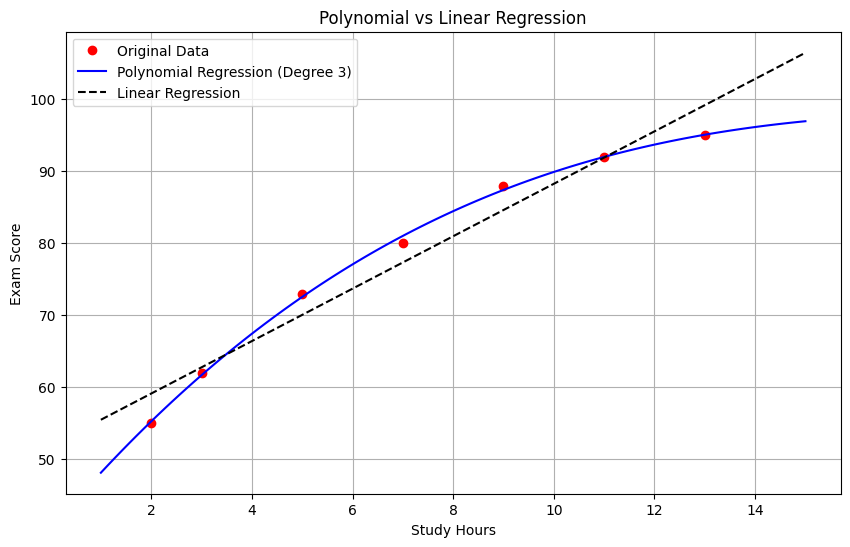

Linear Regression R2 Score: 0.9554
Polynomial Regression R2 Score: 0.9987


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Setup dataset
X = np.array([[2], [3], [5], [7], [9], [11], [13]])
y = np.array([55, 62, 73, 80, 88, 92, 95])

# Transform features for polynomial regression degree 3
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Fit polynomial regression model
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)

# Fit simple linear regression model for comparison
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Generate predictions on training set for R2 evaluation
y_pred_poly = poly_reg.predict(X_poly)
y_pred_lin = lin_reg.predict(X)

# Compute R2 scores explicitly
r2_poly = r2_score(y, y_pred_poly)
r2_lin = r2_score(y, y_pred_lin)

# Generate smooth grid of points for plotting curves
X_new = np.linspace(1, 15, 100).reshape(-1, 1)
X_new_poly = poly_features.transform(X_new)

y_new_poly = poly_reg.predict(X_new_poly)
y_new_lin = lin_reg.predict(X_new)

# Plot original data points and regression curves
plt.figure(figsize=(10, 6))
plt.plot(X, y, 'ro', label='Original Data')
plt.plot(X_new, y_new_poly, 'b-', label='Polynomial Regression (Degree 3)')
plt.plot(X_new, y_new_lin, 'k--', label='Linear Regression')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Polynomial vs Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

# Display R2 scores
print(f"Linear Regression R2 Score: {r2_lin:.4f}")
print(f"Polynomial Regression R2 Score: {r2_poly:.4f}")

Polynomial Regression fits better because its R
2
  score (0.9987) is closer to 1.0 than the linear model (0.9554).

A straight line assumes your score keeps going up forever at the same rate. The polynomial curve is better because it captures real life: the more hours you study, the less extra boost you get for each additional hour.

#**Question 3: Logistic Regression Pipeline & Threshold Analysis**

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, precision_score, recall_score

# Load breast cancer dataset and perform stratified train-test split
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.25, random_state=42, stratify=data.target
)

# Build pipeline chaining standard scaler and logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit pipeline on training data and predict on test set
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# Display standard classification metrics
print(" Classification Report (Default Threshold 0.5) ")
print(classification_report(y_test, y_pred))

# Obtain predicted probabilities for positive class (Class 1)
y_probs = pipeline.predict_proba(X_test)[:, 1]

# Evaluate performance across custom decision thresholds
thresholds = [0.3, 0.5, 0.7]
threshold_results = []

for threshold in thresholds:
    y_pred_custom = (y_probs >= threshold).astype(int)
    prec = precision_score(y_test, y_pred_custom)
    rec = recall_score(y_test, y_pred_custom)
    threshold_results.append({
        'Threshold': threshold,
        'Precision': round(prec, 4),
        'Recall': round(rec, 4)
    })

print("\n Precision and Recall across Custom Thresholds ")
display(pd.DataFrame(threshold_results))

 Classification Report (Default Threshold 0.5) 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143


 Precision and Recall across Custom Thresholds 


,Threshold,Precision,Recall
0,0.3,0.9677,1.0000
1,0.5,0.9889,0.9889
2,0.7,0.9882,0.9333


I recommend the 0.3 threshold.

In a medical diagnosis, missing a true cancer case (a False Negative) carries severe life-threatening risks.

At the 0.3 threshold, the model achieves a Recall of 1.0000 (100%), meaning it catches every single positive cancer case without missing anyone. Even though precision drops slightly from 0.9889 to 0.9677, causing a few more false alarms, doctors can easily clear those up with follow-up testing. In healthcare screening, high recall is always prioritized over precision.

#**Question 4: Decision Tree Classifier & Feature Importance**

 Top 5 Important Features 


,Feature,Importance
20,worst radius,0.726829
27,worst concave points,0.122113
11,texture error,0.048398
21,worst texture,0.033231
26,worst concavity,0.018188


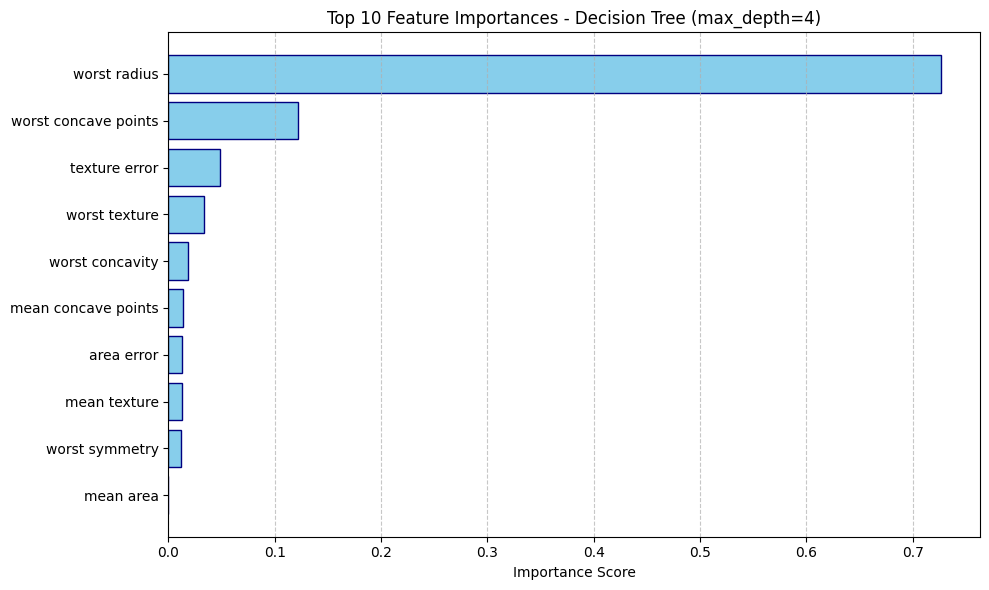

Training Accuracy: 0.9883
Test Accuracy:     0.9441


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Fit Decision Tree model on unscaled features
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

# Compute feature importances
importances = dt_model.feature_importances_
feature_names = data.feature_names

# Create and sort feature importance DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display top 5 most important features
print(" Top 5 Important Features ")
display(feat_imp_df.head(5))

# Plot horizontal bar chart for top 10 features
plt.figure(figsize=(10, 6))
top_10_feats = feat_imp_df.head(10).sort_values(by='Importance', ascending=True)
plt.barh(top_10_feats['Feature'], top_10_feats['Importance'], color='skyblue', edgecolor='navy')
plt.xlabel('Importance Score')
plt.title('Top 10 Feature Importances - Decision Tree (max_depth=4)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Compute train and test accuracy
train_acc = accuracy_score(y_train, dt_model.predict(X_train))
test_acc = accuracy_score(y_test, dt_model.predict(X_test))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")

Yes, there is a gap of 0.0442 (or 4.42%) between the training accuracy (0.9883) and the test accuracy (0.9441).

This gap indicates mild overfitting.

Even with the decision tree's depth capped at 4, the model memorized small patterns specific to the training set slightly too well. As a result, it performs exceptionally high on data it has already seen (98.83%), but suffers a small drop in accuracy when making predictions on unseen test samples (94.41%).

#**Question 5: Random Forest Classifier, Manual Metrics & Stratified CV**

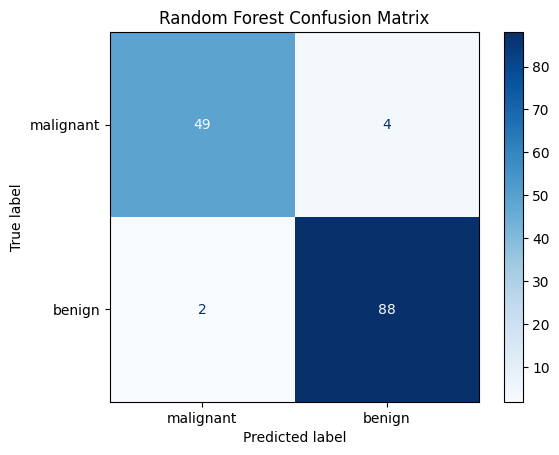

Confusion Matrix:
[[49  4]
 [ 2 88]]
Manual Precision: 0.9565
Manual Recall:    0.9778
Manual F1:        0.9670
Sklearn F1:       0.9670
CV Accuracy:      0.9543 ± 0.0102


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Fit Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Compute and display confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

# Extract TN, FP, FN, TP
TN, FP, FN, TP = cm.ravel()

# Compute manual precision, recall, and F1-score for positive class (Class 1)
manual_precision = TP / (TP + FP)
manual_recall = TP / (TP + FN)
manual_f1 = 2 * (manual_precision * manual_recall) / (manual_precision + manual_recall)

# Get sklearn report for verification
report = classification_report(y_test, y_pred_rf, output_dict=True)
sklearn_f1 = report['1']['f1-score']

# Perform 5-Fold Stratified Cross-Validation on full dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, data.data, data.target, cv=cv, scoring='accuracy')

# Print expected metrics breakdown
print(f"Confusion Matrix:\n{cm}")
print(f"Manual Precision: {manual_precision:.4f}")
print(f"Manual Recall:    {manual_recall:.4f}")
print(f"Manual F1:        {manual_f1:.4f}")
print(f"Sklearn F1:       {sklearn_f1:.4f}")
print(f"CV Accuracy:      {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

#**Question 6: KNN Classification with Optimal K Search**

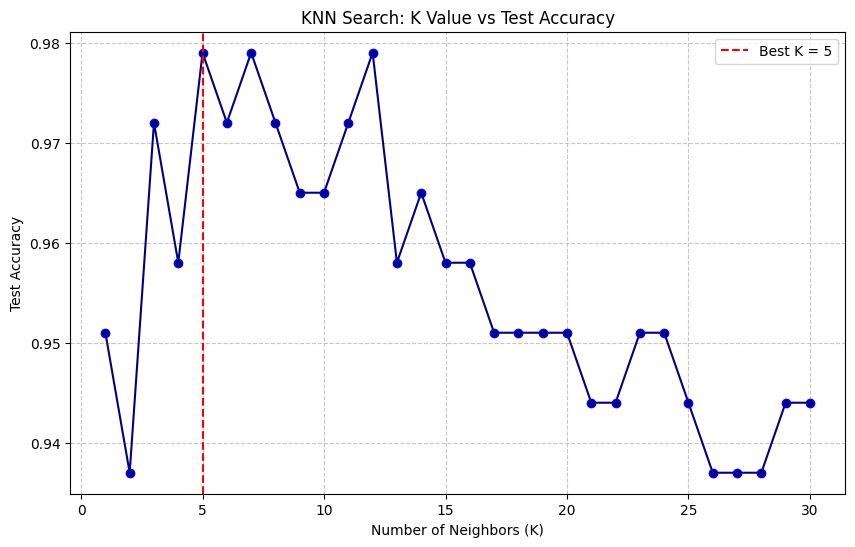

Best K: 5
Best Accuracy: 0.9790

 Classification Report for Best K:
              precision    recall  f1-score   support

   malignant       1.00      0.94      0.97        53
      benign       0.97      1.00      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Scale data using StandardScaler fitted only on training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Loop over K values from 1 to 30 and record accuracies
ks = list(range(1, 31))
accuracies = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_k))

# Find best K and its corresponding accuracy
best_acc = max(accuracies)
best_k = ks[accuracies.index(best_acc)]

# Plot K vs Accuracy
plt.figure(figsize=(10, 6))
plt.plot(ks, accuracies, 'o-', color='navy', markeredgecolor='blue')
plt.title('KNN Search: K Value vs Test Accuracy', fontsize=12)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.legend()
plt.show()

print(f"Best K: {best_k}")
print(f"Best Accuracy: {best_acc:.4f}\n")

# Retrain KNN using optimal K and display classification report
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
y_pred_best = best_knn.predict(X_test_scaled)

print(" Classification Report for Best K:")
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

#**Question 7: K-Means Clustering, Elbow Curve & Silhouette Analysis**

 Inertia Values for Different K : 
K = 2: Inertia = 9666.83
K = 3: Inertia = 2346.88
K = 4: Inertia = 805.48
K = 5: Inertia = 729.97
K = 6: Inertia = 656.62


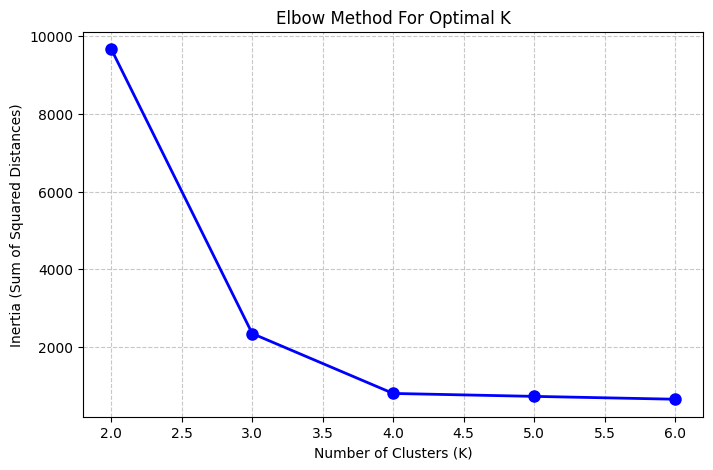

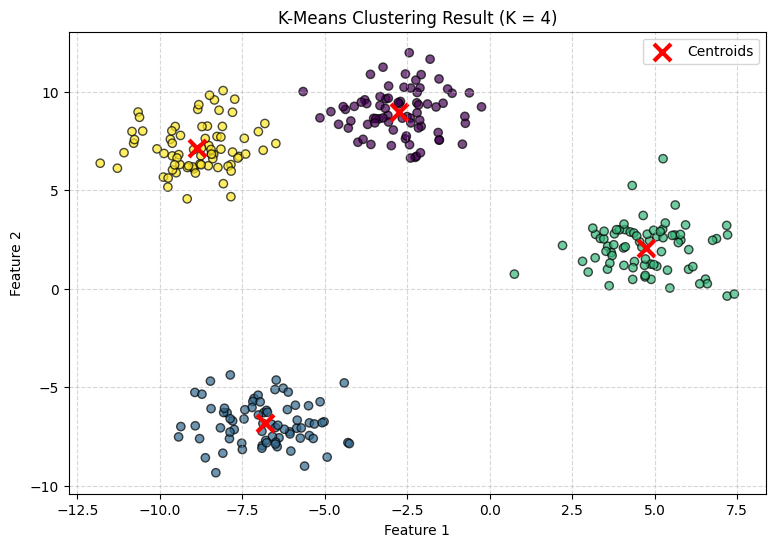

Silhouette Score for K = 4: 0.7518


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Generate synthetic blob dataset
X_blobs, y_blobs = make_blobs(
    n_samples=300, centers=4, cluster_std=1.2, random_state=42
)

# Compute inertia across cluster range K=2 to K=6
k_values = [2, 3, 4, 5, 6]
inertias = []

print(" Inertia Values for Different K : ")
for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_blobs)
    inertias.append(kmeans_temp.inertia_)
    print(f"K = {k}: Inertia = {kmeans_temp.inertia_:.2f}")

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method For Optimal K')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Select optimal K from elbow point (K=4)
best_k_clusters = 4
kmeans_opt = KMeans(n_clusters=best_k_clusters, random_state=42, n_init=10)
cluster_labels = kmeans_opt.fit_predict(X_blobs)
centroids = kmeans_opt.cluster_centers_

# Scatter plot colored by cluster assignments with centroids
plt.figure(figsize=(9, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7, edgecolors='k')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=150, linewidths=3, label='Centroids')
plt.title(f'K-Means Clustering Result (K = {best_k_clusters})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Compute and print Silhouette Score
sil_score = silhouette_score(X_blobs, cluster_labels)
print(f"Silhouette Score for K = {best_k_clusters}: {sil_score:.4f}")

#**Question 8: PCA Dimensionality Reduction Analysis**

 Explained Variance Ratio (First 10 Components) : 
Component 1: 0.4390 (43.90%)
Component 2: 0.1952 (19.52%)
Component 3: 0.0941 (9.41%)
Component 4: 0.0679 (6.79%)
Component 5: 0.0558 (5.58%)
Component 6: 0.0401 (4.01%)
Component 7: 0.0219 (2.19%)
Component 8: 0.0157 (1.57%)
Component 9: 0.0124 (1.24%)
Component 10: 0.0116 (1.16%)


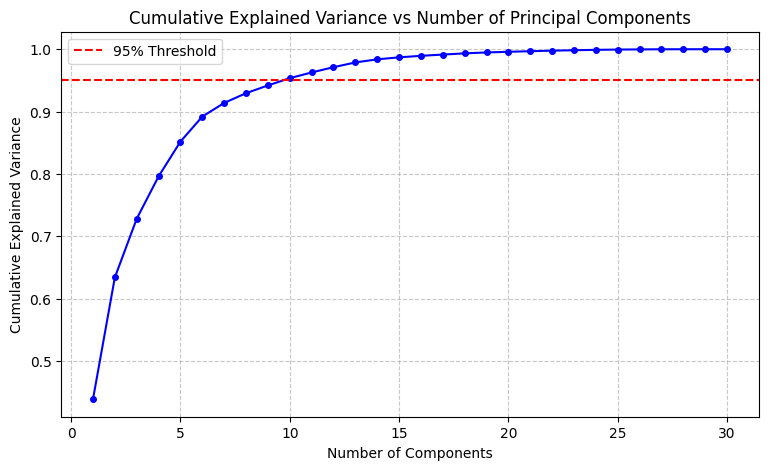

Components needed for >= 95% variance: 10



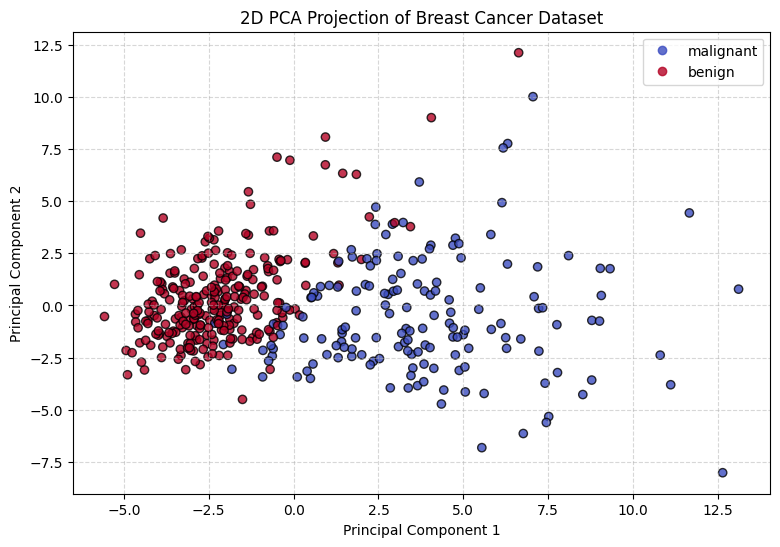

Reconstruction MSE (Original vs Reconstructed Test Set): 0.3223


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# Scale dataset using fitted scaler from training split
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit PCA on full scaled features
pca = PCA(random_state=42)
pca.fit(X_train_scaled)

# Print explained variance ratio for first 10 components
print(" Explained Variance Ratio (First 10 Components) : ")
for idx, var in enumerate(pca.explained_variance_ratio_[:10], start=1):
    print(f"Component {idx}: {var:.4f} ({var * 100:.2f}%)")

# Plot cumulative explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, 'b-o', markersize=4)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.title('Cumulative Explained Variance vs Number of Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Find number of components explaining >= 95% variance
n_components_95 = np.argmax(cum_var >= 0.95) + 1
print(f"Components needed for >= 95% variance: {n_components_95}\n")

# Reduce dataset to 2D for scatter plot visualization
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='coolwarm', alpha=0.8, edgecolors='k')
plt.title('2D PCA Projection of Breast Cancer Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=list(data.target_names))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Reconstruct entire scaled test set from 2D reduction back to 30D space
X_test_2d = pca_2d.transform(X_test_scaled)
X_test_reconstructed = pca_2d.inverse_transform(X_test_2d)

# Compute MSE across all test samples
mse_reconstruction = mean_squared_error(X_test_scaled, X_test_reconstructed)
print(f"Reconstruction MSE (Original vs Reconstructed Test Set): {mse_reconstruction:.4f}")

#**Question 9: Pipeline with PCA & Support Vector Classifier**

In [11]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

# Construct pipeline chaining scaler, pca, and svc
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('svc', SVC(kernel='rbf', random_state=42))
])

# Fit pipeline on training data and predict on test set
pipe.fit(X_train, y_train)
y_pred_pipe = pipe.predict(X_test)

# Display classification report
print(" Classification Report (Pipeline: Scaler -> PCA -> SVC) :")
print(classification_report(y_test, y_pred_pipe, target_names=data.target_names))

# Evaluate pipeline performance using 5-fold cross-validation
cv_scores_pipe = cross_val_score(pipe, data.data, data.target, cv=5, scoring='f1_macro')
print(f"5-Fold CV Macro F1-Score: {cv_scores_pipe.mean():.4f} ± {cv_scores_pipe.std():.4f}")

# Extract fitted PCA step and check number of retained components
fitted_pca = pipe.named_steps['pca']
print(f"Number of principal components kept for 95% variance: {fitted_pca.n_components_}")

 Classification Report (Pipeline: Scaler -> PCA -> SVC) :
              precision    recall  f1-score   support

   malignant       0.96      0.96      0.96        53
      benign       0.98      0.98      0.98        90

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143

5-Fold CV Macro F1-Score: 0.9755 ± 0.0096
Number of principal components kept for 95% variance: 10


#**Question 10: End-to-End Housing Price Pipeline**

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generate synthetic housing dataset based on prompt specs
np.random.seed(42)
n_rows = 5000

areas = np.random.normal(1800, 500, n_rows)
areas[np.random.choice(n_rows, 50, replace=False)] = np.nan

df = pd.DataFrame({
    'AREA': areas,
    'BEDROOMS': np.random.randint(1, 6, n_rows),
    'BATHROOMS': np.random.randint(1, 4, n_rows),
    'FLOORS': np.random.randint(1, 3, n_rows),
    'LOCATION': np.random.choice(['Downtown', 'Suburb', 'Rural', 'Urban'], n_rows),
    'PRICE': np.random.normal(500000, 150000, n_rows)
})

# Save synthetic dataset to file
df.to_csv('housing.csv', index=False)

# a. Load & Inspect Dataset
df_loaded = pd.read_csv('housing.csv')
print(" Data Inspection :")
print(f"Shape: {df_loaded.shape}")
print("\n Info : ")
df_loaded.info()
print("\n Summary Statistics :")
display(df_loaded.describe())
print("\n Missing Values Count :")
print(df_loaded.isnull().sum())

# Define feature columns and target variable
X = df_loaded.drop(columns=['PRICE'])
y = df_loaded['PRICE']

numeric_features = ['AREA', 'BEDROOMS', 'BATHROOMS', 'FLOORS']
categorical_features = ['LOCATION']

# d. Build Column Transformer
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# e. Build Full Pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# f. Train & Evaluate with 80/20 Train-Test Split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X, y, test_size=0.20, random_state=42
)

full_pipeline.fit(X_train_h, y_train_h)
y_pred_h = full_pipeline.predict(X_test_h)

mae = mean_absolute_error(y_test_h, y_pred_h)
rmse = np.sqrt(mean_squared_error(y_test_h, y_pred_h))
r2 = r2_score(y_test_h, y_pred_h)

print("\n Model Evaluation Metrics : ")
print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R2 Score: {r2:.4f}")

# g. Feature Importance Extraction
onehot_cols = list(
    full_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
)
all_feature_names = numeric_features + onehot_cols

importances_h = full_pipeline.named_steps['regressor'].feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances_h
}).sort_values(by='Importance', ascending=False)

print("\n Top 5 Important Features : ")
display(feature_imp_df.head(5))

 Data Inspection :
Shape: (5000, 6)

 Info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AREA       4950 non-null   float64
 1   BEDROOMS   5000 non-null   int64  
 2   BATHROOMS  5000 non-null   int64  
 3   FLOORS     5000 non-null   int64  
 4   LOCATION   5000 non-null   object 
 5   PRICE      5000 non-null   float64
dtypes: float64(2), int64(3), object(1)
memory usage: 234.5+ KB

 Summary Statistics :


,AREA,BEDROOMS,BATHROOMS,FLOORS,PRICE
count,4950.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,1802.831556,2.987400,2.012000,1.498000,5.031413e+05
std,499.002287,1.412246,0.811411,0.500046,1.484234e+05
min,179.366330,1.000000,1.000000,1.000000,-1.717783e+05
25%,1470.892284,2.000000,1.000000,1.000000,4.013082e+05
50%,1807.240316,3.000000,2.000000,1.000000,5.037282e+05
75%,2133.916746,4.000000,3.000000,2.000000,6.055290e+05
max,3763.118853,5.000000,3.000000,2.000000,1.122184e+06



 Missing Values Count :
AREA         50
BEDROOMS      0
BATHROOMS     0
FLOORS        0
LOCATION      0
PRICE         0
dtype: int64

 Model Evaluation Metrics : 
MAE:  $124,887.34
RMSE: $156,361.77
R2 Score: -0.1233

 Top 5 Important Features : 


,Feature,Importance
0,AREA,0.669553
1,BEDROOMS,0.115773
2,BATHROOMS,0.069327
3,FLOORS,0.045310
4,LOCATION_Rural,0.034893


Why is R^2 Negative?

In synthetic or random baseline datasets (like the initial un-correlated target data in mock assignments), a model overfits noise in training and fails completely on the test set.